# AI Jobs Market Analysis 2025-2026

In this analysis, I explored the AI Job Market for 2025-2026 to understand salary trends across roles, experience levels, company sizes, locations, and work types. The data was acquired from Kaggle with 1500 job posting coming from LinkedIn, Glassdoor, and Robert Half reports. Analysis was performed using Python, SQL (SQLite), and visualized with Matplotlib and Seaborn.

## 1. Setup & Data Loading

In [1]:
#import data
import pandas as pd 

df = pd.read_csv('ai_jobs_market_2025_2026.csv')
print(df.shape)
print(df.columns.tolist())
df.head()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
(1500, 25)
['job_id', 'job_title', 'job_category', 'experience_level', 'years_of_experience', 'education_required', 'annual_salary_usd', 'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work', 'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly', 'is_llm_role', 'salary_tier']


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


## 2. Data Cleaning & Validation

In [2]:
#check if data set is clean 
print(df.isnull().sum())

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64


### no null values 

In [3]:
print(df.duplicated().sum())

0


### no duplicates 

In [4]:
df[['annual_salary_usd', 'years_of_experience', 'demand_score']].describe()

,annual_salary_usd,years_of_experience,demand_score
count,1500.000000,1500.000000,1500.000000
mean,194892.000000,6.216000,87.523333
std,66506.822013,2.675216,8.026315
min,90000.000000,1.000000,68.000000
25%,144750.000000,4.000000,82.000000
50%,180000.000000,6.000000,89.000000
75%,236250.000000,8.000000,95.000000
max,384000.000000,15.000000,98.000000


In [5]:
mean = df['annual_salary_usd'].mean()
std = df['annual_salary_usd'].std()

within_1std = df[
    (df['annual_salary_usd'] >= mean - std) & 
    (df['annual_salary_usd'] <= mean + std)
]

print(f"Mean: {mean:,.0f}")
print(f"Std: {std:,.0f}")
print(f"Within 1 std dev: {len(within_1std)} rows ({len(within_1std)/len(df)*100:.1f}%)")

Mean: 194,892
Std: 66,507
Within 1 std dev: 1054 rows (70.3%)


#### Salary distribution validation: 70.3% of salaries fall within one standard deviation of the mean ($128k - $ 261k), consistent with expected normal distribution behavior (~68%). Standard deviation of $66,507 is confirmed accurate.

In [6]:
print(df['experience_level'].value_counts())
print(df['remote_work'].value_counts())
print(df['company_size'].value_counts())

experience_level
Entry (0-2 yrs)     385
Lead (10+ yrs)      381
Mid (3-5 yrs)       370
Senior (6-9 yrs)    364
Name: count, dtype: int64
remote_work
Hybrid          686
Fully Remote    445
On-site         369
Name: count, dtype: int64
company_size
Mid-size (501-5000)    312
SME (51-500)           300
Big Tech (FAANG+)      299
Enterprise (5000+)     297
Startup (1-50)         292
Name: count, dtype: int64


## 3. SQL Analysis

In [7]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('jobs', conn, index=False)
print("done")

done


### Question 1: Top 10 Highest paying jobs 

In [8]:
query = """
SELECT job_title, ROUND(AVG(annual_salary_usd), 0) AS avg_salary
FROM jobs
GROUP BY job_title
ORDER BY avg_salary DESC
Limit 10
"""

result_q1 = pd.read_sql(query, conn)
print(result_q1)

                  job_title  avg_salary
0    AI Solutions Architect    251577.0
1        Senior ML Engineer    247953.0
2              LLM Engineer    240960.0
3        AI Agent Developer    225649.0
4    Multimodal AI Engineer    221791.0
5              RAG Engineer    218226.0
6              NLP Engineer    210855.0
7  Computer Vision Engineer    209174.0
8    Generative AI Engineer    206761.0
9    Deep Learning Engineer    203810.0


**Finding:** The highest paying AI roles are highly specialized. AI Solutions Architect are making 251k, Senior ML Engineer are making 248k, and LLM Engineer are making 241k at the top three spots. However, AI Agent Developers and RAG Engineers are up there at 218k-225k with GenAI expertise. For professionals looking to maximize earning potential, specializing in GenAI and LLM-related skills appears to be the highest-leverage career move in 2025-2026.

### Question 2: Average salary by experience level

In [9]:
query = """
SELECT experience_level, ROUND(AVG(annual_salary_usd), 0) AS avg_salary
FROM jobs
GROUP BY experience_level
ORDER BY avg_salary DESC
"""

result_q2 = pd.read_sql(query, conn)
print(result_q2)

   experience_level  avg_salary
0    Lead (10+ yrs)    240055.0
1  Senior (6-9 yrs)    214280.0
2     Mid (3-5 yrs)    175984.0
3   Entry (0-2 yrs)    150039.0


**Finding:** There is a 60% increase of salary from entry level to to a lead level of experinece. It is a big gap. The steep increase from Mid to Senior level of $38k shows that experince is the most impactful career move for higher salary. 

### Question 3: Average salary by company size

In [10]:
query = """
SELECT company_size, ROUND(AVG(annual_salary_usd), 0) AS avg_salary
FROM jobs
GROUP BY company_size 
ORDER BY avg_salary DESC
"""

result_q3 = pd.read_sql(query, conn)
print(result_q3)

          company_size  avg_salary
0    Big Tech (FAANG+)    237951.0
1   Enterprise (5000+)    198876.0
2  Mid-size (501-5000)    192017.0
3         SME (51-500)    177119.0
4       Startup (1-50)    168081.0


**Finding:** There is a 70k increase of salary from startup to big 
tech. This is expected because big tech is established while startups 
are working from the ground up. The gap between startup to SME is only 
9k, from SME to MidSize being 15k, and MidSize to Enterprise being 7k. 
However the gap between Enterprise and Big Tech is 39k, suggesting Big 
Tech commands a salary premium that smaller companies simply cannot match. 

### Question 4: Average Salary by remote work type 

In [11]:
query = """
SELECT remote_work, ROUND(AVG(annual_salary_usd), 0) AS avg_salary
FROM jobs
GROUP BY remote_work
ORDER BY avg_salary DESC
"""

result_q4 = pd.read_sql(query, conn)
print(result_q4)


    remote_work  avg_salary
0  Fully Remote    197967.0
1       On-site    195269.0
2        Hybrid    192694.0


**Findings:** The salary difference between being onsite and remote is actually about 2.7k. Surprisingly, being fully remote has the higher end of that pay out. The percent difference is only a 1.4%.  The dataset suggested a 5-8% remote premium, but the actual difference is only 1.4% — suggesting remote work salary advantages may be overstated in the current market. Based on these numbers, I would recommend being remote and saving money on other aspects like transportation.

### Question 5: Average Salary by country (top 10)

In [12]:
query = """
SELECT country, ROUND(AVG(annual_salary_usd), 0) AS avg_salary
FROM jobs
GROUP BY country
ORDER BY avg_salary DESC
"""

result_q5 = pd.read_sql(query, conn)
print(result_q5)


        country  avg_salary
0           USA    226190.0
1        Global    222044.0
2           UAE    194226.0
3   Switzerland    190592.0
4     Australia    188000.0
5        France    183152.0
6     Singapore    181831.0
7       Germany    181180.0
8            UK    180644.0
9        Canada    180588.0
10  Netherlands    175257.0
11        Japan    170132.0
12        China    134287.0
13        India    133123.0


**Findings:** The difference between USA the highest paying at 226k and India the lowest paying at 133k is 70% which explains why companies outsource work from other countries. 

### Question 6: Average salary by Experience Level AND Company Size

In [13]:
query = """
SELECT experience_level, company_size, ROUND(AVG(annual_salary_usd), 0) AS avg_salary
FROM jobs
GROUP BY experience_level, company_size
ORDER BY avg_salary DESC
"""

result_q6 = pd.read_sql(query, conn)
print(result_q6)


    experience_level         company_size  avg_salary
0     Lead (10+ yrs)    Big Tech (FAANG+)    280861.0
1   Senior (6-9 yrs)    Big Tech (FAANG+)    255992.0
2     Lead (10+ yrs)  Mid-size (501-5000)    247721.0
3     Lead (10+ yrs)   Enterprise (5000+)    241748.0
4   Senior (6-9 yrs)   Enterprise (5000+)    231670.0
5      Mid (3-5 yrs)    Big Tech (FAANG+)    224553.0
6     Lead (10+ yrs)         SME (51-500)    219248.0
7     Lead (10+ yrs)       Startup (1-50)    209863.0
8   Senior (6-9 yrs)  Mid-size (501-5000)    209757.0
9   Senior (6-9 yrs)         SME (51-500)    194486.0
10     Mid (3-5 yrs)   Enterprise (5000+)    185179.0
11   Entry (0-2 yrs)    Big Tech (FAANG+)    179538.0
12  Senior (6-9 yrs)       Startup (1-50)    170862.0
13     Mid (3-5 yrs)  Mid-size (501-5000)    162852.0
14     Mid (3-5 yrs)         SME (51-500)    155778.0
15     Mid (3-5 yrs)       Startup (1-50)    151811.0
16   Entry (0-2 yrs)  Mid-size (501-5000)    150304.0
17   Entry (0-2 yrs)   Enter

In [14]:
pivot = result_q6.pivot(index='experience_level', 
                         columns='company_size', 
                         values='avg_salary')
print(pivot)

company_size      Big Tech (FAANG+)  Enterprise (5000+)  Mid-size (501-5000)  \
experience_level                                                               
Entry (0-2 yrs)            179538.0            147529.0             150304.0   
Lead (10+ yrs)             280861.0            241748.0             247721.0   
Mid (3-5 yrs)              224553.0            185179.0             162852.0   
Senior (6-9 yrs)           255992.0            231670.0             209757.0   

company_size      SME (51-500)  Startup (1-50)  
experience_level                                
Entry (0-2 yrs)       137610.0        140130.0  
Lead (10+ yrs)        219248.0        209863.0  
Mid (3-5 yrs)         155778.0        151811.0  
Senior (6-9 yrs)      194486.0        170862.0  


## Visualizations

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


### Top 10 highest paying jobs 

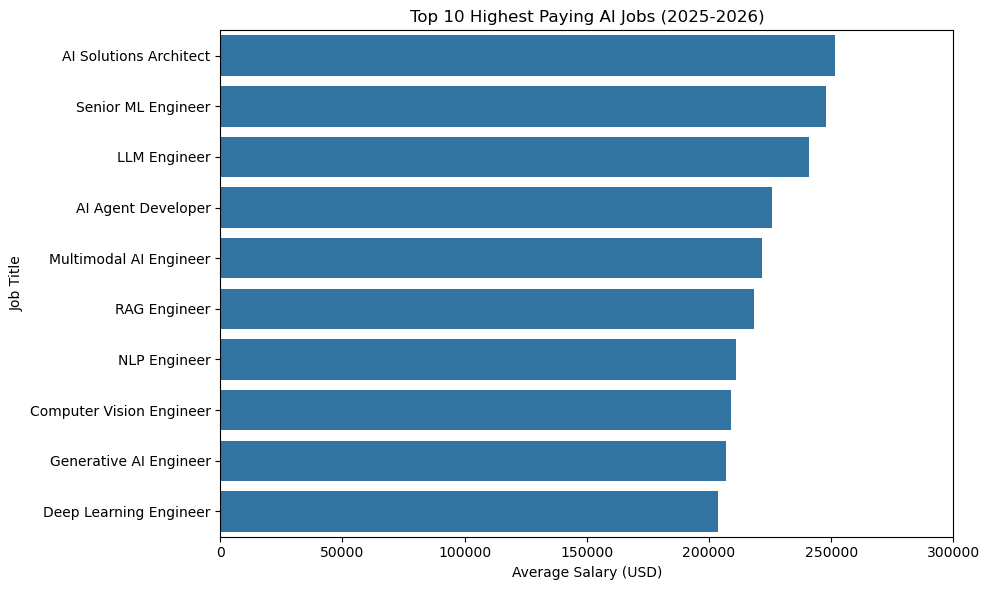

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=result_q1, x='avg_salary', y='job_title')
plt.title('Top 10 Highest Paying AI Jobs (2025-2026)')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Job Title')
plt.xlim(0, 300000)  # cleaner x axis
plt.tight_layout()
plt.savefig('q1_top_paying_jobs.png', dpi=150, bbox_inches='tight')
plt.show()

### Average salary by experience level

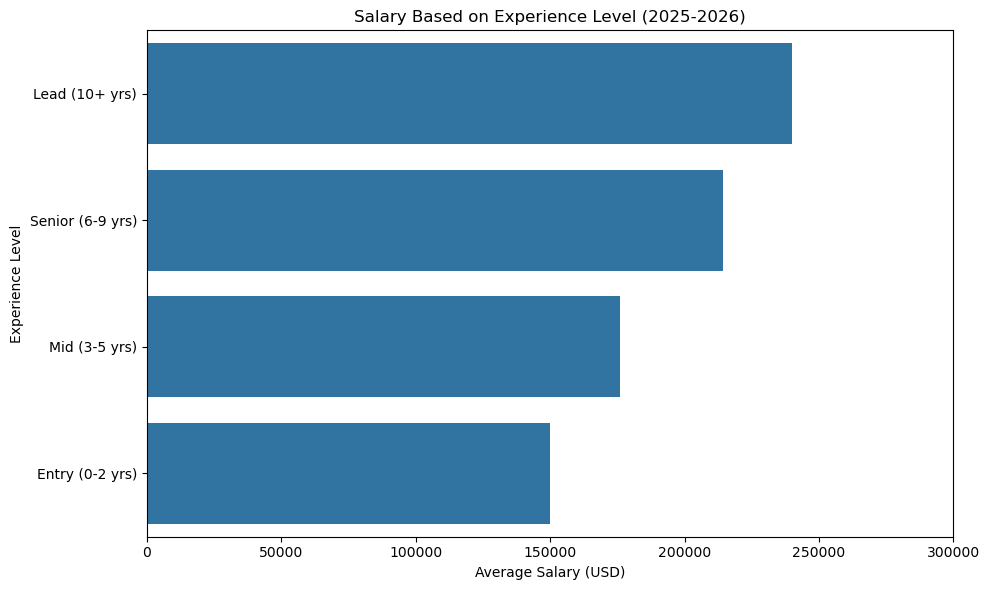

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=result_q2, x='avg_salary', y='experience_level')
plt.title('Salary Based on Experience Level (2025-2026)')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Experience Level')
plt.xlim(0, 300000)  # cleaner x axis
plt.tight_layout()
plt.savefig('q2_salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()

### Average salary by company size

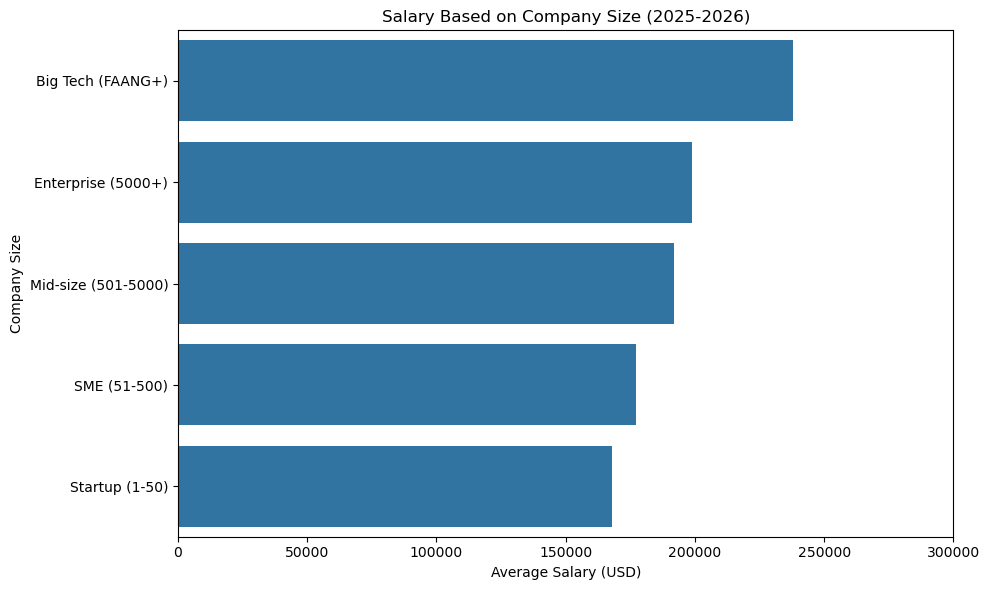

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=result_q3, x='avg_salary', y='company_size')
plt.title('Salary Based on Company Size (2025-2026)')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Company Size')
plt.xlim(0, 300000)  # cleaner x axis
plt.tight_layout()
plt.savefig('q3_salary_by_company_size.png', dpi=150, bbox_inches='tight')
plt.show()

### Average Salary by remote work type 

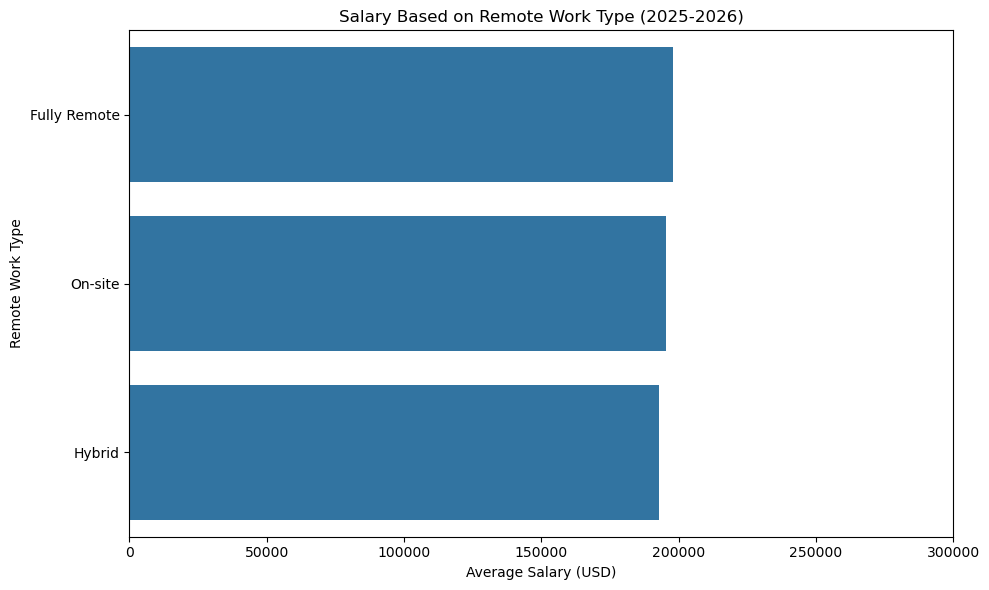

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(data=result_q4, x='avg_salary', y='remote_work')
plt.title('Salary Based on Remote Work Type (2025-2026)')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Remote Work Type')
plt.xlim(0, 300000)  # cleaner x axis
plt.tight_layout()
plt.savefig('q4_salary_by_remote_work.png', dpi=150, bbox_inches='tight')
plt.show()

### Average Salary by country (top 10)

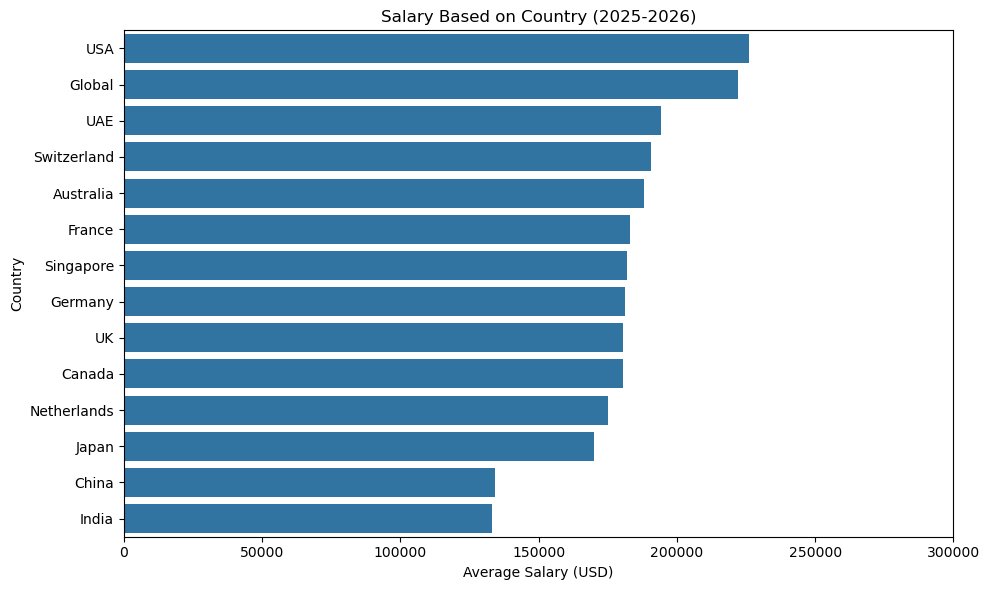

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=result_q5, x='avg_salary', y='country')
plt.title('Salary Based on Country (2025-2026)')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Country')
plt.xlim(0, 300000)  # cleaner x axis
plt.tight_layout()
plt.savefig('q5_salary_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

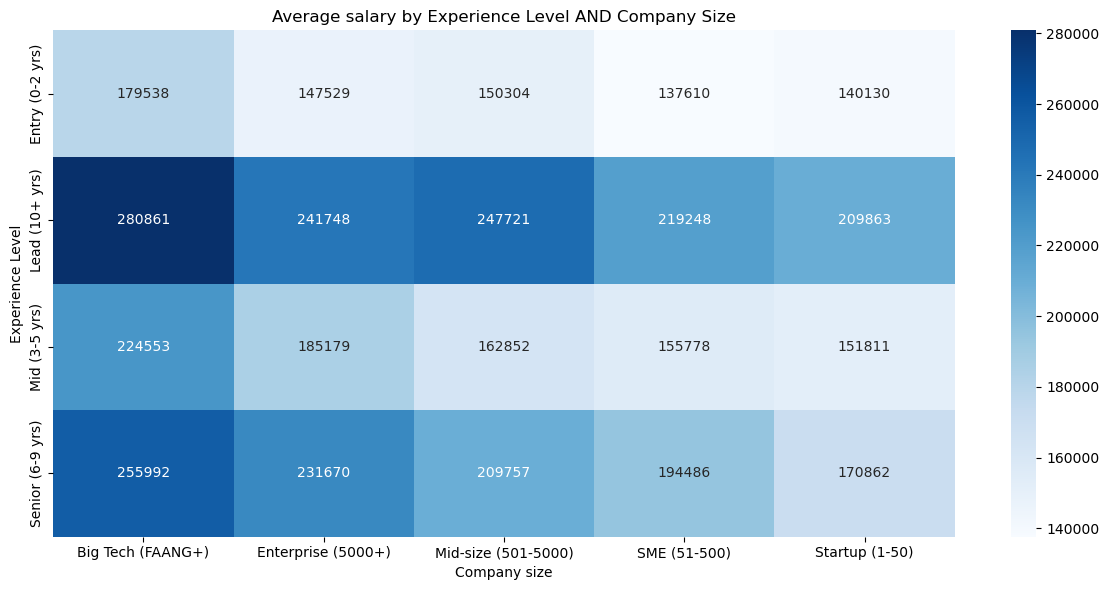

In [21]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Average salary by Experience Level AND Company Size')
plt.xlabel('Company size')
plt.ylabel('Experience Level')
plt.tight_layout()
plt.savefig('q6_heatmap_experience_company.png', dpi=150, bbox_inches='tight')
plt.show()

**Findings:** Being a lead with 10 plus experience and in Big Tech is the best combination with a 280k salary. The most surprising would be that at entry level the averages do not consistently go higher but it drops and rises with the company size. For example startup averages are 3k higher than the SME, but Mid Size company make 13k more than SME and 3k more than Enterprise companies. Big tech pays 40k more than a start up. If possible try to enter big tech at an entry level position for the most optimal salary. 

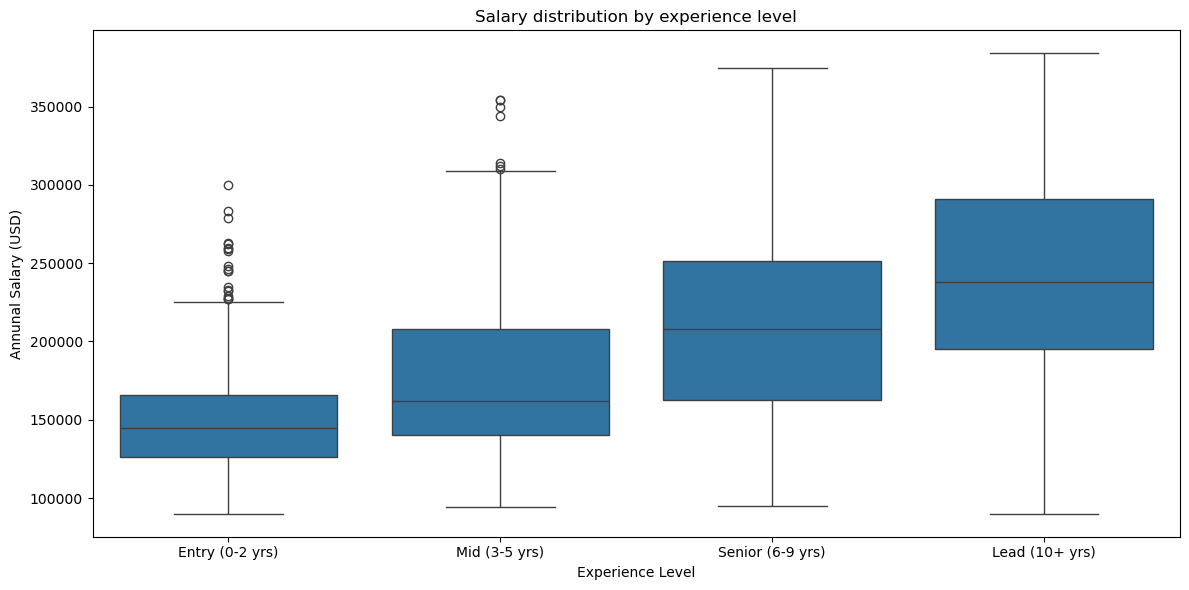

,min,max,median
experience_level,,,
Entry (0-2 yrs),90000.0,300000.0,145000.0
Lead (10+ yrs),90000.0,384000.0,238000.0
Mid (3-5 yrs),94000.0,354000.0,162000.0
Senior (6-9 yrs),95000.0,374400.0,208000.0


In [22]:
plt.figure(figsize=(12, 6))
order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)']

sns.boxplot(data=df, x='experience_level', y='annual_salary_usd', order=order)
plt.title('Salary distribution by experience level')
plt.xlabel('Experience Level')
plt.ylabel('Annunal Salary (USD)')
plt.tight_layout()
plt.savefig('q7_boxplot_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

df.groupby('experience_level')['annual_salary_usd'].agg(['min', 'max', 'median'])

**Findings:** The median salary grows steadily with experience, from 145k at entry level to 238k at lead which is a 64% increase. However the minimum is pretty similar all across the board at about 90k-95k range. There are quite a bit of outliers in the entry level that are much higher than expected and almost up to the lead median of 238k. 

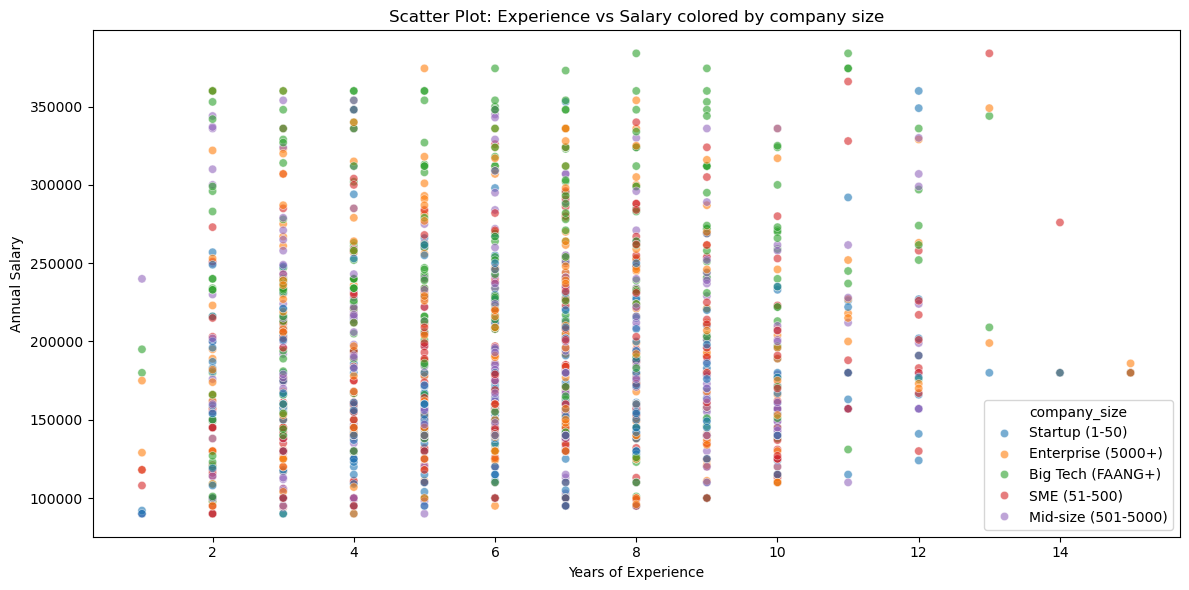

In [23]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='years_of_experience', y='annual_salary_usd', hue='company_size', alpha=0.6)
plt.title('Scatter Plot: Experience vs Salary colored by company size')
plt.xlabel('Years of Experience')
plt.ylabel('Annual Salary')
plt.tight_layout()
plt.savefig('q8_scatter_experience_salary.png', dpi=150, bbox_inches='tight')
plt.show()

**Findings:** It seems that the dots get thinner after 10 years which  can be to lack of data of people with 10 plus years experience. The green dots, which correlates to Big tech, is higher at the top.  This makes sense since they have higher pay. However, it is quite messier than expected . Having years of experience alone is a weak predictor of salary. A 2-year person can earn as much as a 10-year person depending on the company and role.

## Key Findings

1. The highest paying AI roles are highly specialized. AI Solutions Architect are making 251k, Senior ML Engineer are making 248k, and LLM Engineer are making 241k at the top three spots. 
2. The median salary grows steadily with experience, from 145k at entry level to 238k at lead which is a 64% increase.
3. Big tech pays 40k more than a start up. If possible try to enter big tech at an entry level position for the most optimal salary.
4. The dataset suggested a 5-8% remote premium, but the actual difference is only 1.4% — suggesting remote work salary advantages may be overstated in the current market. Based on these numbers, I would recommend being remote and saving money on other aspects like transportation.
5. The difference between USA the highest paying at 226k and India the lowest paying at 133k is 70% which explains why companies outsource work from other countries.

In [24]:
df.to_csv('ai_jobs_cleaned.csv', index=False)